# Daisyworld: отклик на изменение светимости

Сценарий ramp повышает светимость на шагах 201–400 и снижает её на 501–750.
Дополнительно рассчитывается безжизненный контроль с тем же внешним воздействием.

## Основной и контрольный опыты

In [1]:
using DrWatson
@quickactivate "DaisyworldLab"
include(srcdir("experiment_tools.jl"))

living = create_world(scenario=:ramp, seed=165)
control = create_world(scenario=:ramp, init_white=0.0, init_black=0.0, seed=165)
trajectory = history_frame(living, 1000)
control_trajectory = history_frame(control, 1000)
trajectory.control_temperature = control_trajectory.temperature
trajectory.temperature_advantage = abs.(control_trajectory.temperature .- 22.5) .-
                                   abs.(trajectory.temperature .- 22.5)
save_history(trajectory, "daisyworld-luminosity")

Row,time,black,white,total,empty,temperature,luminosity,albedo,regulation_error,control_temperature,temperature_advantage
,Int64,Int64,Int64,Int64,Int64,Float64,Float64,Float64,Float64,Float64,Float64
1,0,180,180,360,540,16.9135,1.0,0.44,5.58646,21.6103,-4.69674
2,1,392,242,634,266,25.5179,1.0,0.428778,3.01794,32.4154,6.89748
3,2,446,360,806,94,29.4005,1.0,0.465667,6.90047,37.818,8.41751
4,3,456,423,879,21,27.7183,1.0,0.4885,5.2183,40.5193,12.801
5,4,461,438,899,1,24.8571,1.0,0.4935,2.3571,41.8699,17.0128
6,5,457,440,897,3,23.0331,1.0,0.494944,0.533051,42.5452,19.5122
7,6,460,439,899,1,22.0153,1.0,0.494056,0.484713,42.8829,19.8982
8,7,460,440,900,0,21.5064,1.0,0.494444,0.993595,43.0517,19.5581
9,8,460,439,899,1,21.252,1.0,0.494056,1.24804,43.1361,19.3881


## Численность, температура, светимость и альбедо

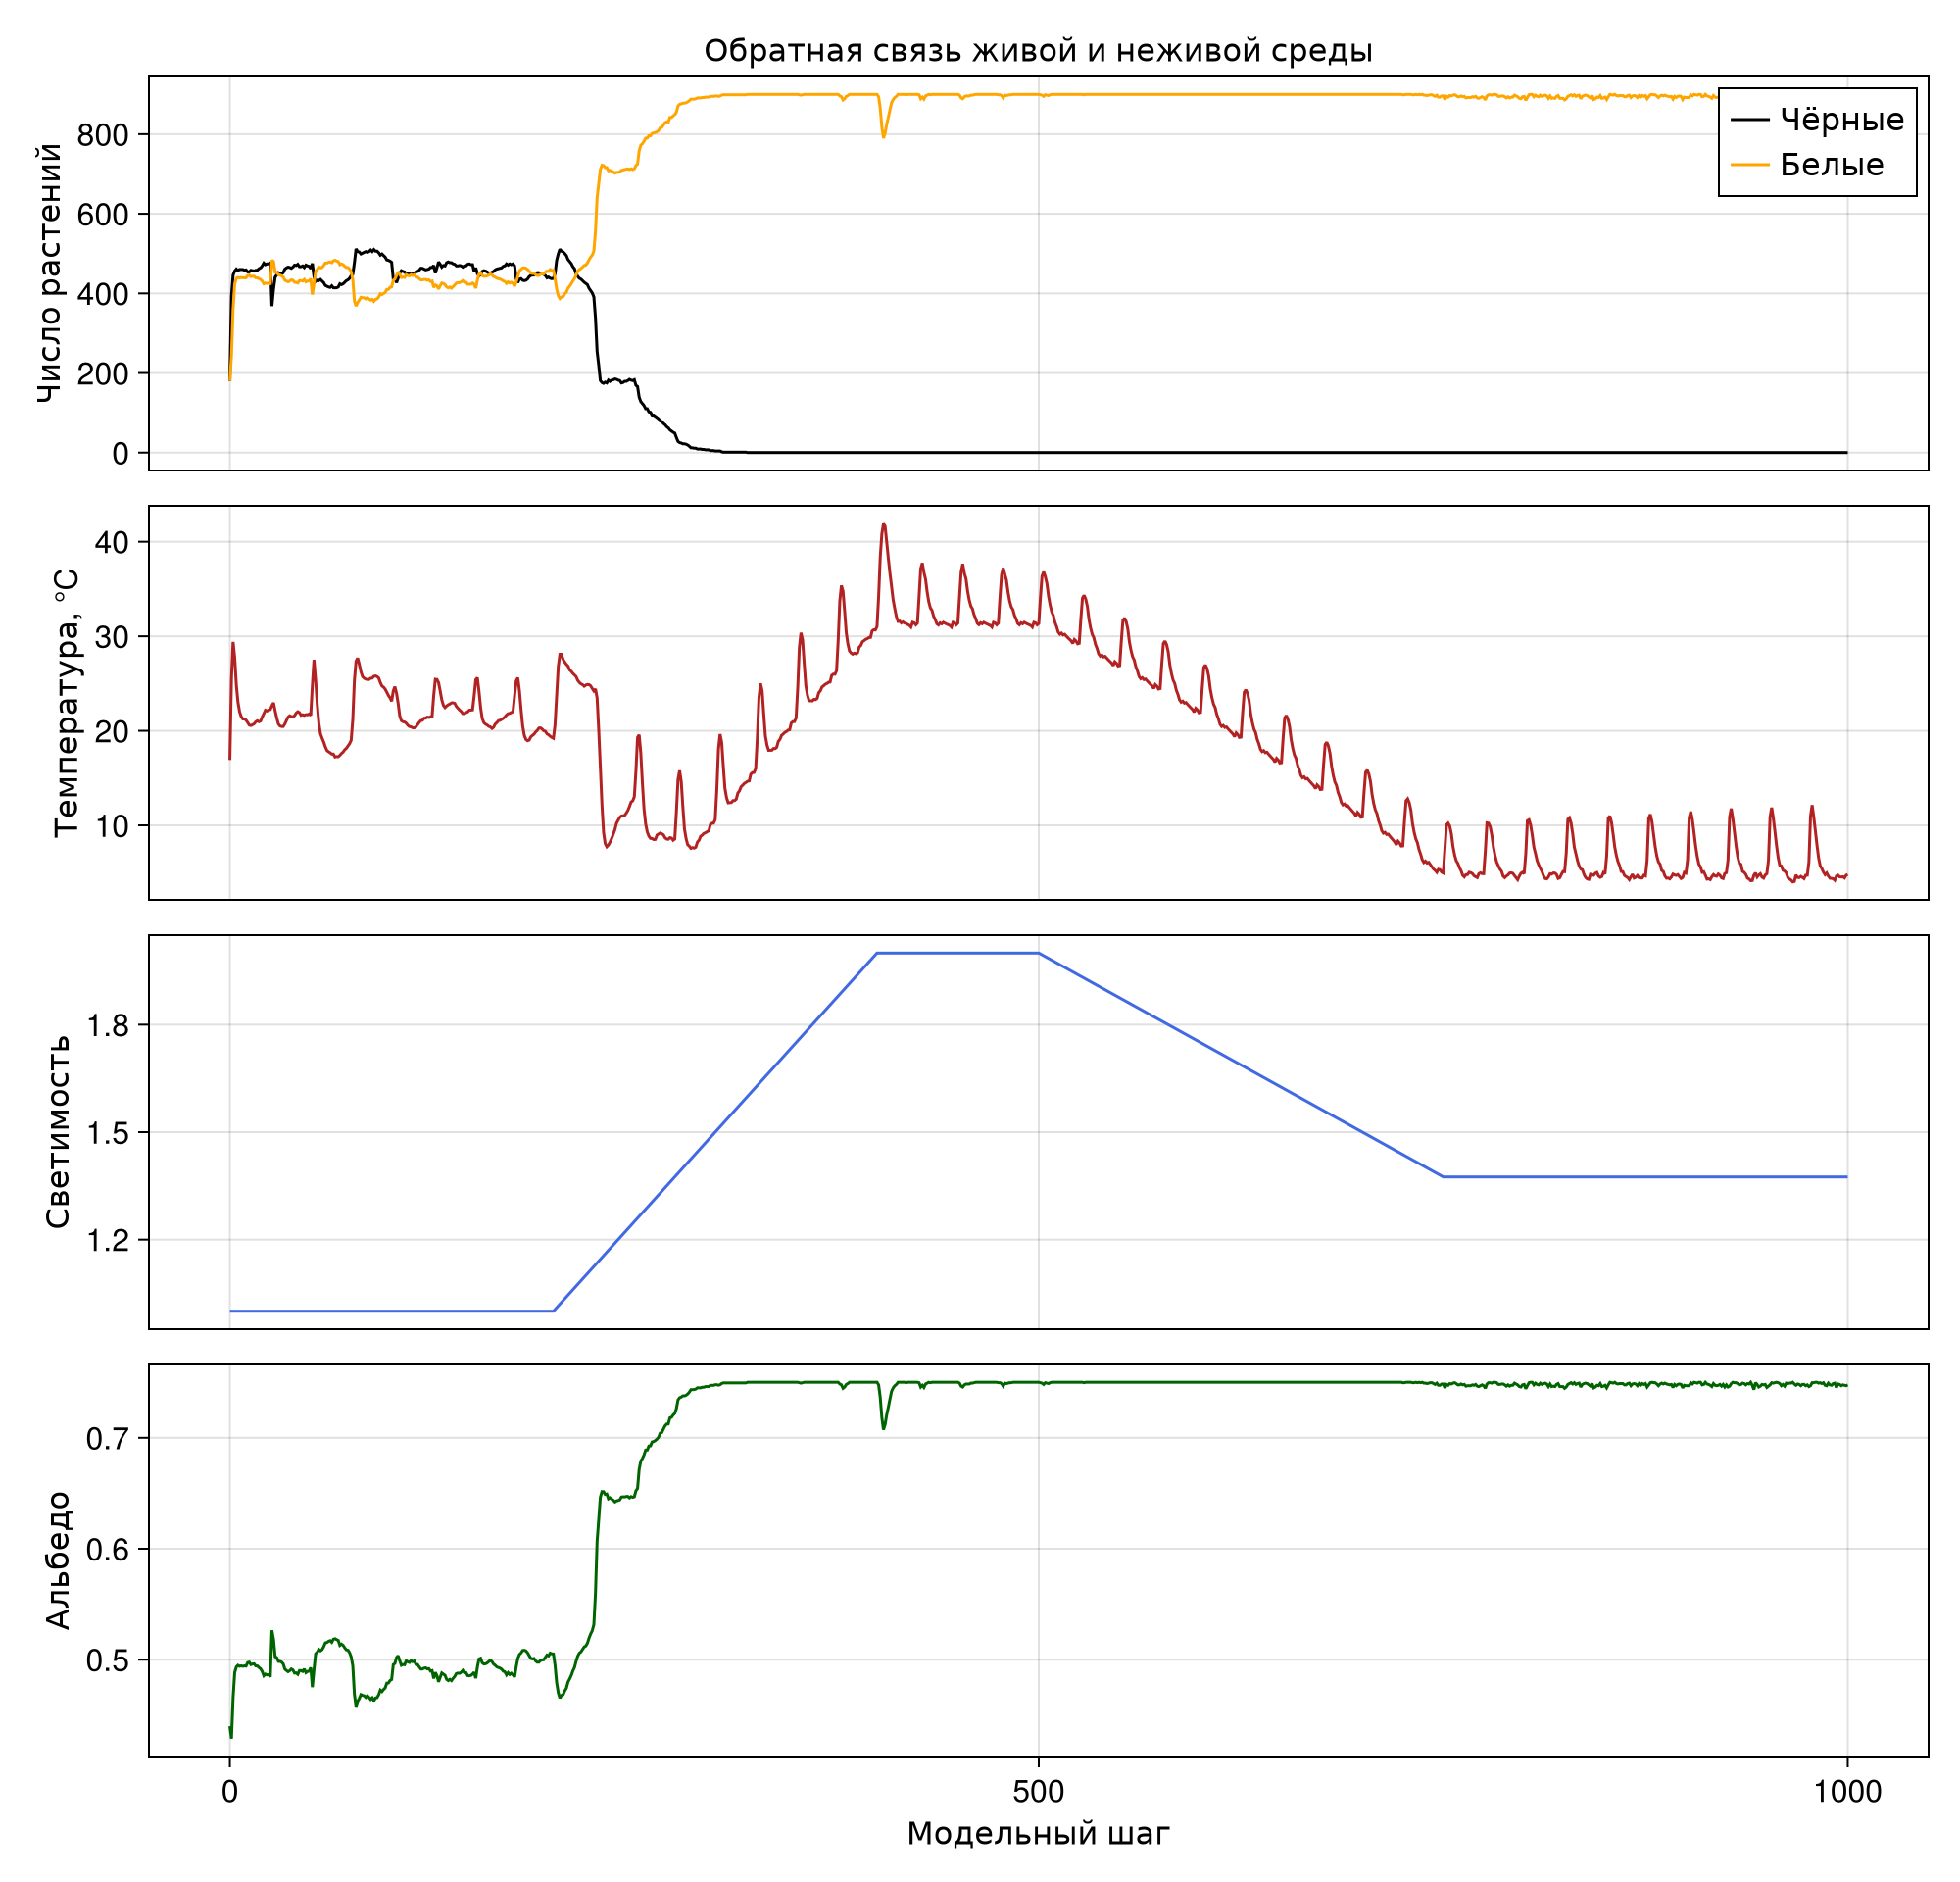

CairoMakie.Screen{IMAGE}


In [2]:
fig = dynamics_figure(trajectory)
save_figure(fig, "daisyworld-luminosity", "coupled-dynamics.png";
            report_name="luminosity-feedback-dynamics.png")
display(fig)

## Контроль саморегуляции

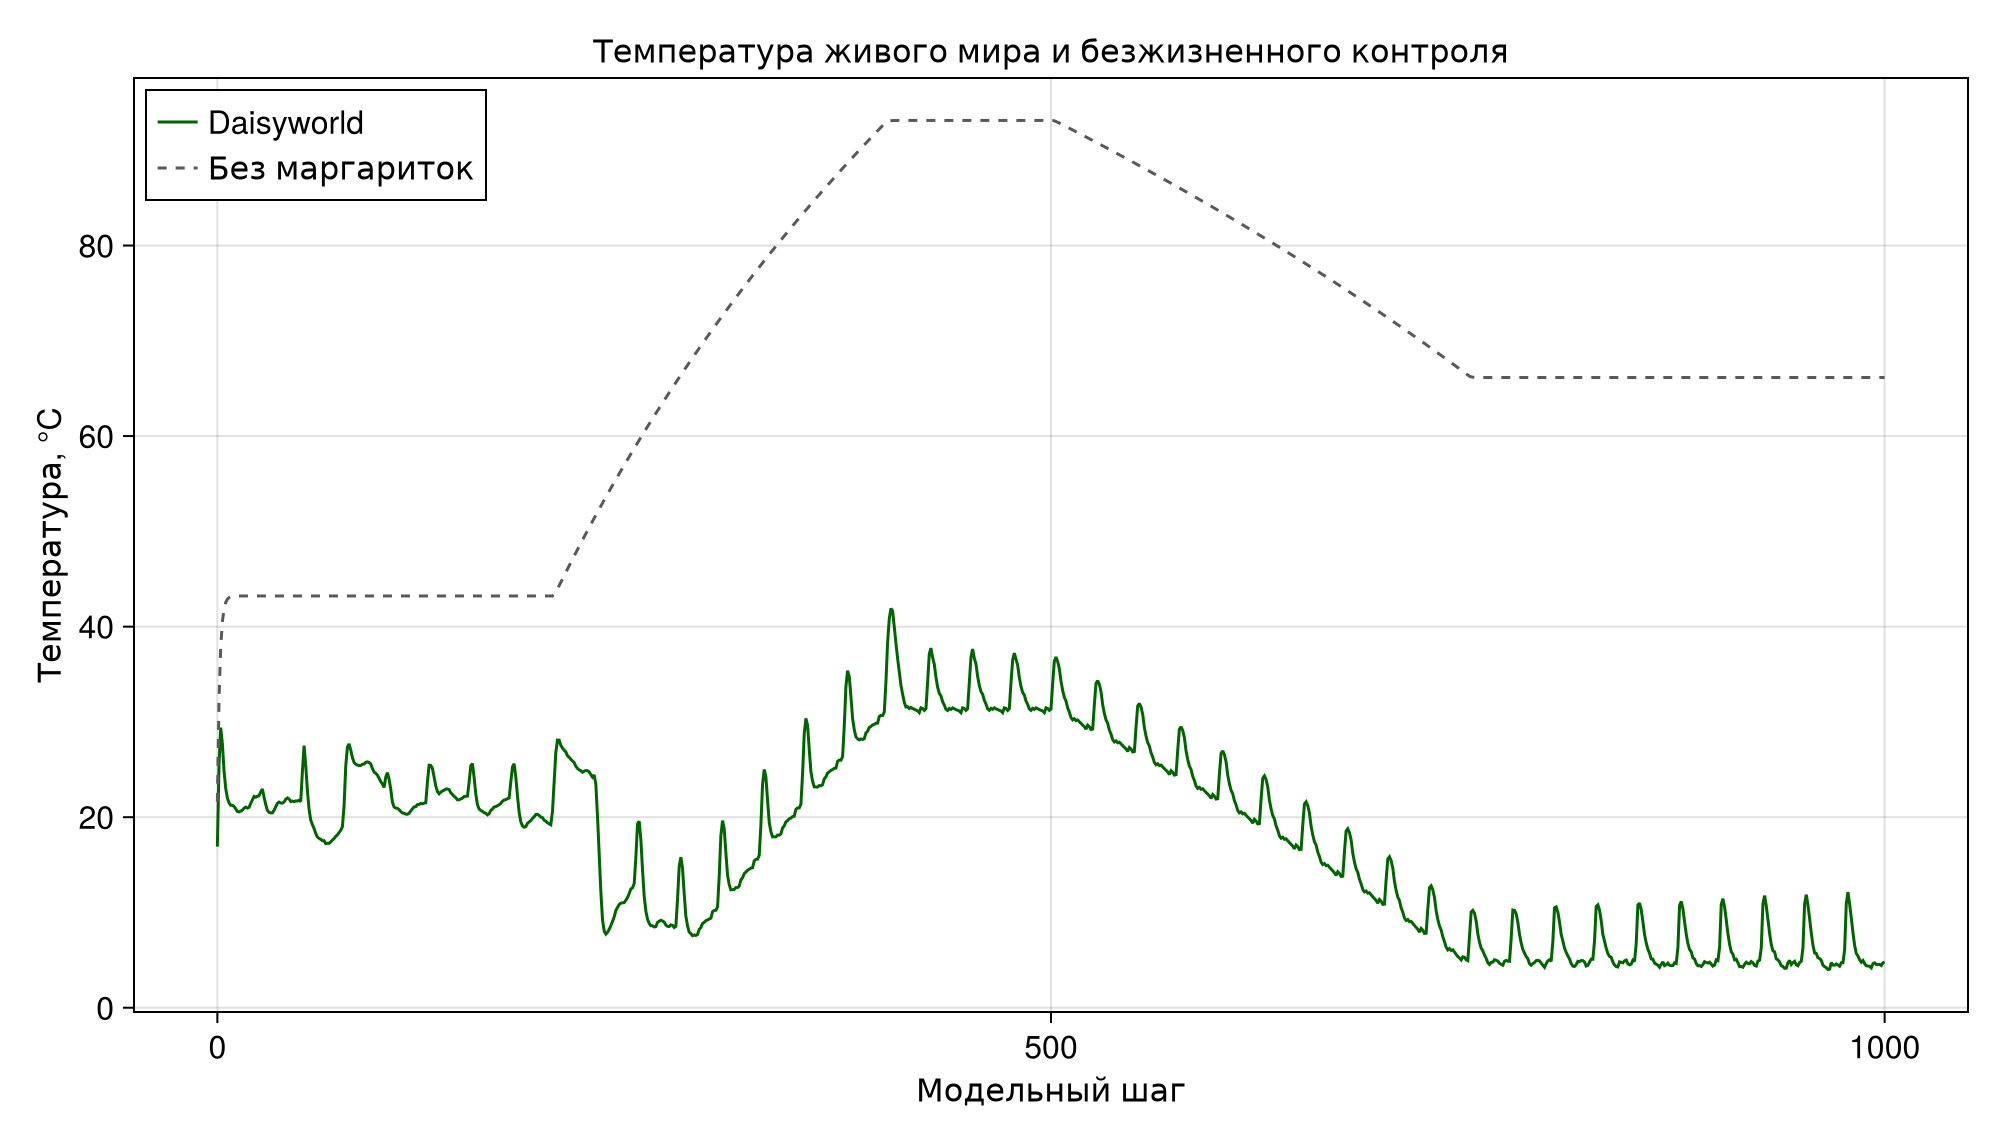

Row,time,black,white,total,empty,temperature,luminosity,albedo,regulation_error,control_temperature,temperature_advantage
,Int64,Int64,Int64,Int64,Int64,Float64,Float64,Float64,Float64,Float64,Float64
1,0,180,180,360,540,16.9135,1.0,0.44,5.58646,21.6103,-4.69674
2,200,438,458,896,4,19.2093,1.0,0.505111,3.29075,43.2206,17.4298
3,400,0,900,900,0,31.0253,2.0,0.75,8.52528,92.7658,61.7405
4,500,0,900,900,0,31.352,2.0,0.75,8.85199,93.1272,61.7752
5,750,0,896,896,4,4.94846,1.375,0.748444,17.5515,66.4103,26.3588
6,1000,0,894,894,6,4.7929,1.375,0.747667,17.7071,66.1492,25.9421


In [3]:
comparison = Figure(size=(1000, 570))
axis = Axis(comparison[1, 1], title="Температура живого мира и безжизненного контроля",
            xlabel="Модельный шаг", ylabel="Температура, °C")
lines!(axis, trajectory.time, trajectory.temperature; color=:darkgreen, label="Daisyworld")
lines!(axis, trajectory.time, trajectory.control_temperature; color=:gray35,
       linestyle=:dash, label="Без маргариток")
axislegend(axis; position=:lt)
save_figure(comparison, "daisyworld-luminosity", "biotic-vs-abiotic.png";
            report_name="biotic-abiotic-temperature.png")
display(comparison)
trajectory[[1, 201, 401, 501, 751, 1001], :]